In [1]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt
import seaborn as sns
import sklearn



%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', 300)
pd.set_option('display.max_rows', 300)

In [2]:
read = pd.read_csv('H2HBABBA1887.csv')

In [3]:
df = pd.DataFrame(read)

In [4]:
df.isna().sum()

business_code                 0
cust_number                   0
name_customer                 0
clear_date                10000
buisness_year                 0
doc_id                        0
posting_date                  0
document_create_date          0
document_create_date.1        0
due_in_date                   0
invoice_currency              0
document type                 0
posting_id                    0
area_business             50000
total_open_amount             0
baseline_create_date          0
cust_payment_terms            0
invoice_id                    9
isOpen                        0
dtype: int64

In [5]:
# Removing NaN(area_business) column
df = df.drop(['area_business'], axis=1)

In [6]:
df

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen
0,U001,0200769623,WAL-MAR in,NaN,2020.0,1.930815e+09,2020-04-28,20200422,20200428,20200513.0,USD,RV,1.0,6361.07,20200428.0,NAH4,1.930815e+09,1
1,U001,0200729828,KENNETH foundation,2019-09-25 00:00:00,2019.0,1.929826e+09,2019-09-06,20190903,20190906,20190926.0,USD,RV,1.0,27848.46,20190906.0,NAD1,1.929826e+09,0
2,U001,CCU013,KRAFT F trust,NaN,2020.0,1.930666e+09,2020-03-16,20200317,20200316,20200316.0,USD,RV,1.0,5095.68,20200316.0,NAX2,1.930666e+09,1
3,U001,0200780383,MEIJ us,2019-09-30 00:00:00,2019.0,1.929852e+09,2019-09-09,20190909,20190909,20190924.0,USD,RV,1.0,81781.59,20190909.0,NAA8,1.929852e+09,0
4,U001,0200792293,UNIFIE llc,2019-11-22 00:00:00,2019.0,1.930113e+09,2019-11-05,20191105,20191105,20191120.0,USD,RV,1.0,67352.17,20191105.0,NAA8,1.930113e+09,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,U001,0200726979,BJ'S associates,2019-01-30 00:00:00,2019.0,1.928608e+09,2019-01-15,20190111,20190115,20190130.0,USD,RV,1.0,290.59,20190115.0,NAA8,1.928608e+09,0
49996,U001,0200705742,DOT us,2019-02-13 00:00:00,2019.0,1.928704e+09,2019-01-29,20190129,20190129,20190213.0,USD,RV,1.0,1957.09,20190129.0,NAA8,1.928704e+09,0
49997,U001,0200759878,SA systems,NaN,2020.0,1.930838e+09,2020-05-02,20200429,20200502,20200517.0,USD,RV,1.0,7595.36,20200502.0,NAH4,1.930838e+09,1
49998,U001,0200726979,BJ'S co,2020-03-09 00:00:00,2020.0,1.930560e+09,2020-02-22,20200224,20200222,20200308.0,USD,RV,1.0,522.38,20200222.0,NAA8,1.930560e+09,0


#### create date is target column

# Removing the datapoints where the target value is null

In [7]:
main_train = df[df.clear_date.isnull() == False]
main_test = df[df.clear_date.isnull() == True]

In [8]:
#Preprocess the data 
main_train.shape

(40000, 18)

In [9]:
main_train.isna().sum()

business_code             0
cust_number               0
name_customer             0
clear_date                0
buisness_year             0
doc_id                    0
posting_date              0
document_create_date      0
document_create_date.1    0
due_in_date               0
invoice_currency          0
document type             0
posting_id                0
total_open_amount         0
baseline_create_date      0
cust_payment_terms        0
invoice_id                9
isOpen                    0
dtype: int64

# Preprocessing

### Null Imputation

In [10]:
# Checking the column having NaN row 
main_train[main_train.invoice_id.isnull()]

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen
8363,CA02,0140104409,LOB associates,2019-04-17 00:00:00,2019.0,9.500000e+09,2019-03-29,20190329,20190314,20190324.0,CAD,X2,1.0,698.60,20190314.0,CA10,NaN,0
12386,CA02,0140104409,LOB co,2019-12-27 00:00:00,2019.0,9.500000e+09,2019-03-29,20190329,20190228,20190310.0,CAD,X2,1.0,173.44,20190228.0,CA10,NaN,0
16029,CA02,0140104409,LOB associates,2019-12-27 00:00:00,2019.0,9.500000e+09,2019-03-29,20190329,20180626,20180706.0,CAD,X2,1.0,279.60,20180626.0,CA10,NaN,0
16348,CA02,0140106054,TREE trust,2019-05-31 00:00:00,2019.0,9.500000e+09,2019-03-29,20190329,20190307,20190317.0,CAD,X2,1.0,1751.14,20190307.0,CA10,NaN,0
27159,CA02,0140104429,COSTCO in,2019-05-14 00:00:00,2019.0,9.500000e+09,2019-03-29,20190329,20190311,20190321.0,CAD,X2,1.0,5353.20,20190311.0,CA10,NaN,0
35364,CA02,0140106054,TREE llc,2019-05-22 00:00:00,2019.0,9.500000e+09,2019-03-29,20190329,20190301,20190311.0,CAD,X2,1.0,21245.76,20190301.0,CA10,NaN,0
36289,CA02,0140106054,TREE llc,2019-05-06 00:00:00,2019.0,9.500000e+09,2019-03-29,20190329,20190208,20190218.0,CAD,X2,1.0,938.43,20190208.0,CA10,NaN,0
37333,CA02,0140106054,TREE in,2019-05-06 00:00:00,2019.0,9.500000e+09,2019-03-29,20190329,20190128,20190207.0,CAD,X2,1.0,12636.00,20190128.0,CA10,NaN,0
49883,CA02,0140106379,QUAL llc,2019-05-14 00:00:00,2019.0,9.500000e+09,2019-04-30,20190430,20190312,20190322.0,CAD,X2,1.0,6732.00,20190312.0,CA10,NaN,0


In [11]:
# Dropping the null invoice id rows
main_train = main_train[main_train.invoice_id.isnull()==False]

In [12]:
# Creating function to change alphaNumeric to numeric
def strToNumeric(numStr):
    num = 0
    for i, c in enumerate(reversed(numStr)):
        num += numStr.index(c) * (len(numStr) ** i)
    return(num)

In [13]:
# Process to change alphaNumeric 'cust_number' to numeric
# Applying function to it

length = len(main_train['cust_number'])

for idx in range(length):
    if(main_train['cust_number'].values[idx].isnumeric()):
        main_train['cust_number'].values[idx] = pd.to_numeric(main_train['cust_number'].values[idx])
    else:
        main_train['cust_number'].values[idx] = strToNumeric(main_train['cust_number'].values[idx])
    


In [14]:
# final step to convert data type
main_train['cust_number'] = main_train['cust_number'].astype(int)

In [15]:
# Checking the details of main_train
main_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 39991 entries, 1 to 49999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   business_code           39991 non-null  object 
 1   cust_number             39991 non-null  int32  
 2   name_customer           39991 non-null  object 
 3   clear_date              39991 non-null  object 
 4   buisness_year           39991 non-null  float64
 5   doc_id                  39991 non-null  float64
 6   posting_date            39991 non-null  object 
 7   document_create_date    39991 non-null  int64  
 8   document_create_date.1  39991 non-null  int64  
 9   due_in_date             39991 non-null  float64
 10  invoice_currency        39991 non-null  object 
 11  document type           39991 non-null  object 
 12  posting_id              39991 non-null  float64
 13  total_open_amount       39991 non-null  float64
 14  baseline_create_date    39991 non-null

### Date Time Conversion

In [16]:
main_train['clear_date'] = pd.to_datetime(main_train['clear_date'])
main_train['posting_date'] = pd.to_datetime(main_train['posting_date'])

# Converting clear_date datatype to float
# main_train['clear_date'] = pd.to_numeric(main_train['clear_date'], downcast='float')

In [17]:
# Creating a new column delay from float data type columns
main_train['Delay'] = main_train['due_in_date'] - main_train['baseline_create_date']

In [18]:
# Sorting data with respect to posting date
main_train.sort_values(by=['posting_date'])

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen,Delay
37337,U001,200706844,WINC corporation,2019-01-14,2019.0,1.928543e+09,2018-12-30,20181230,20181230,20190114.0,USD,RV,1.0,13975.59,20181230.0,NAA8,1.928543e+09,0,8884.0
40786,CA02,140104409,LOB,2019-01-18,2019.0,2.960521e+09,2018-12-30,20181230,20181230,20190114.0,CAD,RV,1.0,101583.73,20190104.0,CA10,2.960521e+09,0,10.0
10325,U001,200726979,BJ'S,2019-01-15,2019.0,1.928527e+09,2018-12-30,20181231,20181230,20190114.0,USD,RV,1.0,146.96,20181230.0,NAA8,1.928527e+09,0,8884.0
16374,U001,200769623,WAL-MAR in,2019-01-09,2019.0,1.928539e+09,2018-12-30,20181229,20181230,20190114.0,USD,RV,1.0,4763.88,20181230.0,NAH4,1.928539e+09,0,8884.0
33189,U001,200780849,LAUREL systems,2019-01-14,2019.0,1.928544e+09,2018-12-30,20181230,20181230,20190114.0,USD,RV,1.0,25252.26,20181230.0,NAA8,1.928544e+09,0,8884.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44306,U001,200126819,MCLANE systems,2020-03-18,2020.0,1.930558e+09,2020-02-27,20200222,20200227,20200313.0,USD,RV,1.0,53264.58,20200227.0,NAA8,1.930558e+09,0,86.0
18190,U001,200418007,AM us,2020-03-13,2020.0,1.930548e+09,2020-02-27,20200220,20200227,20200313.0,USD,RV,1.0,4171.53,20200227.0,NAA8,1.930548e+09,0,86.0
35280,U001,100004536,BAS systems,2020-03-12,2020.0,1.930571e+09,2020-02-27,20200226,20200227,20200313.0,USD,RV,1.0,18509.90,20200227.0,NAA8,1.930571e+09,0,86.0
3785,U001,200943275,US llc,2020-03-13,2020.0,1.930581e+09,2020-02-27,20200227,20200227,20200313.0,USD,RV,1.0,37837.60,20200227.0,NAA8,1.930581e+09,0,86.0


## Split Data

In [19]:
# Converting the main_train into X and y so that we can pass it onto train_test_split function

# X --> contains the dataframe without the target i.e price
X = main_train.drop('clear_date',axis=1)

# y --> contains only the target value 
y = main_train['clear_date']

In [20]:
#splitting the data first into two part -- doing a 70:30 split i.e 30% data fed to intermediate test data set
from sklearn.model_selection import train_test_split
X_train,X_inter_test,y_train,y_inter_test = train_test_split(X,y,test_size=0.3,random_state=0 , shuffle = False)

In [21]:
# Furthur splitting from resultant split into train, val, test.
X_val,X_test,y_val,y_test = train_test_split(X_inter_test,y_inter_test,test_size=0.5,random_state=0 , shuffle = False)

In [22]:
# Checking total rows and colums in each
X_train.shape , X_val.shape , X_test.shape

((27993, 18), (5999, 18), (5999, 18))

## EDA

<AxesSubplot:xlabel='clear_date', ylabel='Density'>

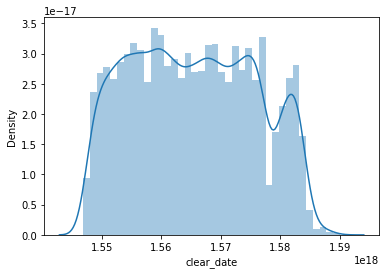

In [23]:
# distribution of the target column 
# right skewed distribution
# outliers present but not that significant , hence  
sns.distplot(y_train)

In [24]:
X_train.merge(y_train,on = X_train.index)

,key_0,business_code,cust_number,name_customer,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen,Delay,clear_date
0,1,U001,200729828,KENNETH foundation,2019.0,1.929826e+09,2019-09-06,20190903,20190906,20190926.0,USD,RV,1.0,27848.46,20190906.0,NAD1,1.929826e+09,0,20.0,2019-09-25
1,3,U001,200780383,MEIJ us,2019.0,1.929852e+09,2019-09-09,20190909,20190909,20190924.0,USD,RV,1.0,81781.59,20190909.0,NAA8,1.929852e+09,0,15.0,2019-09-30
2,4,U001,200792293,UNIFIE llc,2019.0,1.930113e+09,2019-11-05,20191105,20191105,20191120.0,USD,RV,1.0,67352.17,20191105.0,NAA8,1.930113e+09,0,15.0,2019-11-22
3,5,U001,200833713,JETRO llc,2019.0,1.929002e+09,2019-03-20,20190320,20190320,20190404.0,USD,RV,1.0,1696.56,20190320.0,NAA8,1.929002e+09,0,84.0,2019-04-09
4,6,U001,200769623,WAL-MAR corp,2020.0,1.930510e+09,2020-02-10,20200210,20200210,20200225.0,USD,RV,1.0,14213.45,20200210.0,NAH4,1.930510e+09,0,15.0,2020-02-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27988,35095,U001,200769623,WAL-MAR,2019.0,1.930169e+09,2019-11-19,20191119,20191119,20191204.0,USD,RV,1.0,45839.94,20191119.0,NAH4,1.930169e+09,0,85.0,2019-12-02
27989,35096,U001,200769623,WAL-MAR corp,2019.0,1.928914e+09,2019-03-07,20190306,20190307,20190322.0,USD,RV,1.0,756.28,20190307.0,NAH4,1.928914e+09,0,15.0,2019-03-18
27990,35097,U013,569,HEINZ trust,2019.0,1.991821e+09,2019-01-24,20190124,20190124,20190310.0,USD,RV,1.0,18755.43,20190124.0,NAVF,1.991821e+09,0,186.0,2019-03-22
27991,35098,U001,200881076,ALBERT trust,2019.0,1.929456e+09,2019-06-07,20190607,20190607,20190622.0,USD,RV,1.0,165.63,20190607.0,NAA8,1.929456e+09,0,15.0,2019-06-24


In [25]:
X_train.cust_number.nunique()

942

In [26]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 27993 entries, 1 to 35099
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   business_code           27993 non-null  object        
 1   cust_number             27993 non-null  int32         
 2   name_customer           27993 non-null  object        
 3   buisness_year           27993 non-null  float64       
 4   doc_id                  27993 non-null  float64       
 5   posting_date            27993 non-null  datetime64[ns]
 6   document_create_date    27993 non-null  int64         
 7   document_create_date.1  27993 non-null  int64         
 8   due_in_date             27993 non-null  float64       
 9   invoice_currency        27993 non-null  object        
 10  document type           27993 non-null  object        
 11  posting_id              27993 non-null  float64       
 12  total_open_amount       27993 non-null  float6

# Feature Engg

In [27]:
# Encoding business_code using LabelEncoder
from sklearn.preprocessing import LabelEncoder
Business_encoder = LabelEncoder()
Business_encoder.fit(X_train['business_code'])
X_train['business_code_enc'] = Business_encoder.transform(X_train['business_code'])

In [28]:
X_train[['business_code_enc','business_code']]

,business_code_enc,business_code
1,1,U001
3,1,U001
4,1,U001
5,1,U001
6,1,U001
...,...,...
35095,1,U001
35096,1,U001
35097,5,U013
35098,1,U001


In [29]:
X_val['business_code_enc'] = Business_encoder.transform(X_val['business_code'])
X_test['business_code_enc'] = Business_encoder.transform(X_test['business_code'])

In [30]:
X_test[['business_code_enc','business_code']]

,business_code_enc,business_code
42592,1,U001
42593,1,U001
42594,1,U001
42598,1,U001
42599,1,U001
...,...,...
49994,1,U001
49995,1,U001
49996,1,U001
49998,1,U001


In [31]:
# Droping business_code column after encoding
X_train.drop(['business_code'], axis =1,inplace=True)
X_val.drop(['business_code'],axis=1 , inplace=True)
X_test.drop(['business_code'],axis=1 , inplace=True)

In [32]:
Cust_payment_encoder = LabelEncoder()
Cust_payment_encoder.fit(X_train['cust_payment_terms'])
X_train['cust_payment_terms_enc'] = Cust_payment_encoder.transform(X_train['cust_payment_terms'])

In [33]:
X_train['cust_payment_terms_enc']

1        31
3        23
4        23
5        23
6        37
         ..
35095    37
35096    37
35097    59
35098    23
35099    37
Name: cust_payment_terms_enc, Length: 27993, dtype: int32

In [34]:
X_val['cust_payment_terms_enc'] = LabelEncoder().fit_transform(list(X_val['cust_payment_terms'].values))
X_test['cust_payment_terms_enc'] = Cust_payment_encoder.transform(X_test['cust_payment_terms'])

In [35]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 27993 entries, 1 to 35099
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   cust_number             27993 non-null  int32         
 1   name_customer           27993 non-null  object        
 2   buisness_year           27993 non-null  float64       
 3   doc_id                  27993 non-null  float64       
 4   posting_date            27993 non-null  datetime64[ns]
 5   document_create_date    27993 non-null  int64         
 6   document_create_date.1  27993 non-null  int64         
 7   due_in_date             27993 non-null  float64       
 8   invoice_currency        27993 non-null  object        
 9   document type           27993 non-null  object        
 10  posting_id              27993 non-null  float64       
 11  total_open_amount       27993 non-null  float64       
 12  baseline_create_date    27993 non-null  float6

In [36]:
# function will delete a column from train , val and test
def origin_snap(col ,traindf = X_train,valdf = X_val,testdf = X_test):
    traindf.drop(col, axis =1,inplace=True)
    valdf.drop(col,axis=1 , inplace=True)
    testdf.drop(col,axis=1 , inplace=True)

    return traindf,valdf ,testdf

In [37]:
# wrote a custom function to do a status check  on all the dataframes 
def status_check(traindf = X_train,valdf = X_val,testdf = X_test):
    print(traindf.info())
    print("-----------------------------")
    print(traindf.shape,valdf.shape,testdf.shape)
    print("-------------Train Null Count---------------")
    print(traindf.isna().sum())
    print("-------------Test Null Count---------------")
    print(testdf.isna().sum())    
    print("-------------Val Null Count---------------")
    print(valdf.isna().sum())

In [38]:
#Date of journey
#0 --> Monday , 6 --> Sunday
X_train['day_of_posting_week'] = X_train['posting_date'].dt.weekday 
X_val['day_of_posting_week'] = X_val['posting_date'].dt.weekday 
X_test['day_of_posting_week'] = X_test['posting_date'].dt.weekday

In [39]:
#extract day,month and year 

X_train['day_of_posting'] = X_train['posting_date'].dt.day
X_train['month_of_posting'] = X_train['posting_date'].dt.month
X_train['year_of_posting'] = X_train['posting_date'].dt.year

X_val['day_of_posting'] = X_val['posting_date'].dt.day
X_val['month_of_posting'] = X_val['posting_date'].dt.month
X_val['year_of_posting'] = X_val['posting_date'].dt.year


X_test['day_of_posting'] = X_test['posting_date'].dt.day
X_test['month_of_posting'] = X_test['posting_date'].dt.month
X_test['year_of_posting'] = X_test['posting_date'].dt.year

In [40]:
X_train ,X_val, X_test = origin_snap(['posting_date'])

In [41]:
# Snapping name_customer, document type, invoice_currency and cust_payment_terms 
# As it doesn't effect much

X_train ,X_val, X_test = origin_snap(['invoice_currency','cust_payment_terms', 'name_customer', 'document type'])

In [42]:
status_check()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 27993 entries, 1 to 35099
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cust_number             27993 non-null  int32  
 1   buisness_year           27993 non-null  float64
 2   doc_id                  27993 non-null  float64
 3   document_create_date    27993 non-null  int64  
 4   document_create_date.1  27993 non-null  int64  
 5   due_in_date             27993 non-null  float64
 6   posting_id              27993 non-null  float64
 7   total_open_amount       27993 non-null  float64
 8   baseline_create_date    27993 non-null  float64
 9   invoice_id              27993 non-null  float64
 10  isOpen                  27993 non-null  int64  
 11  Delay                   27993 non-null  float64
 12  business_code_enc       27993 non-null  int32  
 13  cust_payment_terms_enc  27993 non-null  int32  
 14  day_of_posting_week     27993 non-null

# Feature Selection

<AxesSubplot:title={'center':'Pearson Correlation of Features'}>

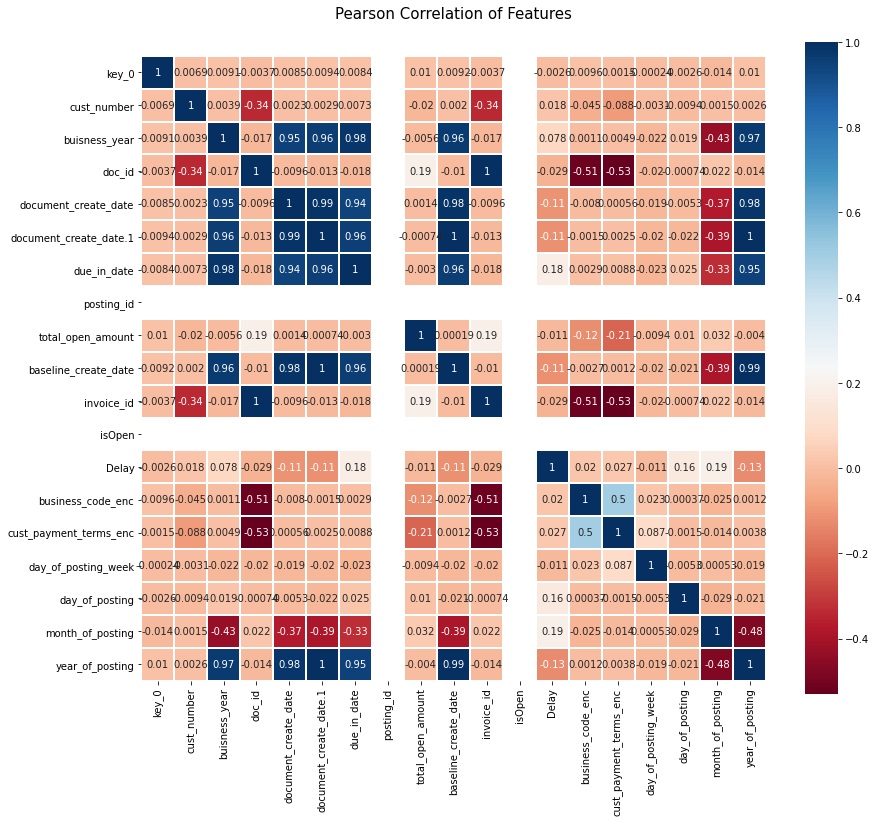

In [43]:
# Checking the correlation of columns

colormap = plt.cm.RdBu
plt.figure(figsize=(14,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(X_train.merge(y_train , on = X_train.index ).corr(),linewidths=0.1,vmax=1.0, 
            square=True, cmap=colormap, linecolor='white', annot=True)

In [44]:
X_train ,X_val, X_test = origin_snap(['posting_id','isOpen'])

In [45]:
from sklearn.feature_selection import VarianceThreshold
sel = VarianceThreshold(0.8)
sel.fit(X_train)

VarianceThreshold(threshold=0.8)

In [46]:
sel.variances_

array([1.78602099e+15, 1.15230516e-01, 7.63933784e+16, 1.07156180e+07,
       1.06061531e+07, 1.08095784e+07, 1.64913053e+09, 1.06128414e+07,
       7.63933784e+16, 8.95127369e+05, 2.81320051e-01, 1.35976176e+02,
       3.29303292e+00, 7.58157222e+01, 1.22002579e+01, 1.16167959e-01])

# Modelling

## Tree based model

In [47]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state=0 , max_depth=5)

In [48]:
regressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=0)

In [49]:
y_predict = regressor.predict(X_val)

y_val = pd.to_numeric(y_val, downcast='float')

In [50]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_val, y_predict, squared=False)

994258739593388.9

In [51]:
y_predict_test = regressor.predict(X_test)

y_test = pd.to_numeric(y_val, downcast='float')

mean_squared_error(y_test, y_predict_test, squared=False)

1.4419846861836568e+16

In [52]:
# Applying on main_test
main_test

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen
0,U001,0200769623,WAL-MAR in,NaN,2020.0,1.930815e+09,2020-04-28,20200422,20200428,20200513.0,USD,RV,1.0,6361.07,20200428.0,NAH4,1.930815e+09,1
2,U001,CCU013,KRAFT F trust,NaN,2020.0,1.930666e+09,2020-03-16,20200317,20200316,20200316.0,USD,RV,1.0,5095.68,20200316.0,NAX2,1.930666e+09,1
10,U001,0200769623,WAL-MAR corp,NaN,2020.0,1.930711e+09,2020-03-28,20200327,20200328,20200412.0,USD,RV,1.0,31228.04,20200328.0,NAH4,1.930711e+09,1
11,U001,0200769623,WAL-MAR corporation,NaN,2020.0,1.930843e+09,2020-05-01,20200430,20200501,20200516.0,USD,RV,1.0,40491.29,20200501.0,NAH4,1.930843e+09,1
16,U001,0200769623,WAL-MAR corp,NaN,2020.0,1.930838e+09,2020-04-29,20200429,20200429,20200514.0,USD,RV,1.0,18453.58,20200429.0,NAH4,1.930838e+09,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49980,U001,0200707822,PUBLI us,NaN,2020.0,1.930862e+09,2020-05-06,20200506,20200506,20200521.0,USD,RV,1.0,171301.72,20200506.0,NAA8,1.930862e+09,1
49982,U001,0200020431,DEC co,NaN,2020.0,1.930826e+09,2020-04-25,20200425,20200425,20200509.0,USD,RV,1.0,2241.22,20200416.0,NAM4,1.930826e+09,1
49983,U001,0200769623,WAL-MAR,NaN,2020.0,1.930760e+09,2020-04-09,20200407,20200409,20200424.0,USD,RV,1.0,6540.07,20200409.0,NAH4,1.930760e+09,1
49993,U001,0200779906,BOZZU corp,NaN,2020.0,1.930660e+09,2020-03-17,20200316,20200317,20200521.0,USD,RV,1.0,6276.46,20200317.0,NAGD,1.930660e+09,1


## Preprocessing

### Null / constant / duplicate drop same steps

In [53]:
main_test.isna().sum()

business_code                 0
cust_number                   0
name_customer                 0
clear_date                10000
buisness_year                 0
doc_id                        0
posting_date                  0
document_create_date          0
document_create_date.1        0
due_in_date                   0
invoice_currency              0
document type                 0
posting_id                    0
total_open_amount             0
baseline_create_date          0
cust_payment_terms            0
invoice_id                    0
isOpen                        0
dtype: int64

### Converting cust_number to integer

In [54]:
# Process to change alphaNumeric 'cust_number' to numeric
# Applying function to it

length = len(main_test['cust_number'])

for idx in range(length):
    if(main_test['cust_number'].values[idx].isnumeric()):
        main_test['cust_number'].values[idx] = pd.to_numeric(main_test['cust_number'].values[idx])
    else:
        main_test['cust_number'].values[idx] = strToNumeric(main_test['cust_number'].values[idx])


In [55]:
# final step to convert data type
main_test['cust_number'] = main_test['cust_number'].astype(int)

In [56]:
main_test['Delay'] = main_test['due_in_date'] - main_test['baseline_create_date']

#### Drop clear_date column as we are going to predict that + its null

In [57]:
X_main_test = main_test.drop(['clear_date'],axis=1)

# ALSO LETS DROP CLEAR DATE FROM MAIN TEST ITSELF
main_test.drop(['clear_date'], inplace =True,axis=1)

In [58]:
X_main_test['posting_date'] = pd.to_datetime(X_main_test['posting_date'])

## Feature Engg

In [59]:
# checking unique values in each column
main_test.nunique()

business_code                5
cust_number                535
name_customer             1754
buisness_year                1
doc_id                    9722
posting_date                82
document_create_date        90
document_create_date.1      82
due_in_date                127
invoice_currency             2
document type                1
posting_id                   1
total_open_amount         9069
baseline_create_date        83
cust_payment_terms          41
invoice_id                9722
isOpen                       1
Delay                       47
dtype: int64

In [60]:
# Detail info for columns having less then 50 unique values
for col in main_test.columns:
    if main_test[col].nunique()<= 50:
        print(main_test[col].value_counts())
        print('-------------------------')

U001    9184
CA02     703
U013      79
U002      27
U005       7
Name: business_code, dtype: int64
-------------------------
2020.0    10000
Name: buisness_year, dtype: int64
-------------------------
USD    9297
CAD     703
Name: invoice_currency, dtype: int64
-------------------------
RV    10000
Name: document type, dtype: int64
-------------------------
1.0    10000
Name: posting_id, dtype: int64
-------------------------
NAA8    4096
NAH4    3011
CA10     696
NAC6     379
NAGD     307
NAM4     260
NAAX     254
NAU5     191
NAM2     118
NAD1     103
NAG2      88
NA32      72
NAX2      70
NA10      63
NAD5      59
NAVE      56
NAM1      44
NAAW      38
NAWP      15
NAVF      12
NAB1       9
NA38       9
NABG       6
NAVQ       5
NA84       5
NAUZ       5
NACH       4
NACE       4
NA3B       3
NAVD       3
NAM3       3
NAD4       2
C106       2
NACG       1
NA3F       1
CAB1       1
NA25       1
NAUP       1
B052       1
BR56       1
CAX2       1
Name: cust_payment_terms, dtype: int6

In [61]:

# Clubbing cust_payment_terms with less occurance
main_test['cust_payment_terms'] = np.where(
    main_test['cust_payment_terms'].isin(
        ['NAVD', 'NAM3', 'NA3B' 'C106', 'NAD4', 'NACG', 'NA3F', 'NAUP', 'CAX2',
         'CAB1', 'B052', 'NA25', 'BR56' ]
    ),"other_terms",main_test['cust_payment_terms'])


In [62]:
X_main_test['business_code_enc'] = Business_encoder.transform(X_main_test['business_code'])
X_main_test['cust_payment_terms_enc'] = LabelEncoder().fit_transform(X_main_test['cust_payment_terms'])

X_main_test['day_of_posting_week'] = X_main_test['posting_date'].dt.weekday
X_main_test['day_of_posting'] = X_main_test['posting_date'].dt.day
X_main_test['month_of_posting'] = X_main_test['posting_date'].dt.month
X_main_test['year_of_posting'] = X_main_test['posting_date'].dt.year

In [63]:
def main_snap(col, testdf = X_main_test):
    testdf.drop(col, axis =1,inplace=True)
    
    return testdf

In [64]:
X_main_test = main_snap(['invoice_currency','cust_payment_terms', 'document type', 'posting_date'])

In [65]:
X_main_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10000 entries, 0 to 49997
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   business_code           10000 non-null  object 
 1   cust_number             10000 non-null  int32  
 2   name_customer           10000 non-null  object 
 3   buisness_year           10000 non-null  float64
 4   doc_id                  10000 non-null  float64
 5   document_create_date    10000 non-null  int64  
 6   document_create_date.1  10000 non-null  int64  
 7   due_in_date             10000 non-null  float64
 8   posting_id              10000 non-null  float64
 9   total_open_amount       10000 non-null  float64
 10  baseline_create_date    10000 non-null  float64
 11  invoice_id              10000 non-null  float64
 12  isOpen                  10000 non-null  int64  
 13  Delay                   10000 non-null  float64
 14  business_code_enc       10000 non-null

In [66]:
X_main_test = main_snap(['business_code', 'posting_id', 'isOpen', 'name_customer'])

In [67]:
final_result = regressor.predict(X_main_test)

In [68]:
final_result = pd.Series(final_result,name='clear_date')

In [69]:
final_result = pd.to_datetime(final_result, format='%Y%m%d %H:%M:%S.%f')

In [70]:
# resetting the index of main test so that we can merge price series with it
main_test.reset_index(drop=True,inplace=True)

In [71]:
Final = main_test.merge(final_result , on = X_main_test.index )
Final

,key_0,business_code,cust_number,name_customer,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen,Delay,clear_date
0,0,U001,200769623,WAL-MAR in,2020.0,1.930815e+09,2020-04-28,20200422,20200428,20200513.0,USD,RV,1.0,6361.07,20200428.0,NAH4,1.930815e+09,1,85.0,2020-03-14 00:04:26.666664960
1,2,U001,569,KRAFT F trust,2020.0,1.930666e+09,2020-03-16,20200317,20200316,20200316.0,USD,RV,1.0,5095.68,20200316.0,NAX2,1.930666e+09,1,0.0,2020-03-14 00:04:26.666664960
2,10,U001,200769623,WAL-MAR corp,2020.0,1.930711e+09,2020-03-28,20200327,20200328,20200412.0,USD,RV,1.0,31228.04,20200328.0,NAH4,1.930711e+09,1,84.0,2020-03-14 00:04:26.666664960
3,11,U001,200769623,WAL-MAR corporation,2020.0,1.930843e+09,2020-05-01,20200430,20200501,20200516.0,USD,RV,1.0,40491.29,20200501.0,NAH4,1.930843e+09,1,15.0,2020-03-14 00:04:26.666664960
4,16,U001,200769623,WAL-MAR corp,2020.0,1.930838e+09,2020-04-29,20200429,20200429,20200514.0,USD,RV,1.0,18453.58,20200429.0,NAH4,1.930838e+09,1,85.0,2020-03-14 00:04:26.666664960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,49980,U001,200707822,PUBLI us,2020.0,1.930862e+09,2020-05-06,20200506,20200506,20200521.0,USD,RV,1.0,171301.72,20200506.0,NAA8,1.930862e+09,1,15.0,2020-03-14 00:04:26.666664960
9996,49982,U001,200020431,DEC co,2020.0,1.930826e+09,2020-04-25,20200425,20200425,20200509.0,USD,RV,1.0,2241.22,20200416.0,NAM4,1.930826e+09,1,93.0,2020-03-14 00:04:26.666664960
9997,49983,U001,200769623,WAL-MAR,2020.0,1.930760e+09,2020-04-09,20200407,20200409,20200424.0,USD,RV,1.0,6540.07,20200409.0,NAH4,1.930760e+09,1,15.0,2020-03-14 00:04:26.666664960
9998,49993,U001,200779906,BOZZU corp,2020.0,1.930660e+09,2020-03-17,20200316,20200317,20200521.0,USD,RV,1.0,6276.46,20200317.0,NAGD,1.930660e+09,1,204.0,2020-03-14 00:04:26.666664960
